# Dimensionality Reduction: GPU PCA

This notebook is a **GPU-first PCA workflow** for emotion classification.

What it does:
- loads one feature CSV
- separates metadata from model features
- trains GPU baseline models on the raw features
- applies GPU `PCA` on standardized training features
- retrains and compares GPU model performance
- visualizes explained variance by component
- saves PCA component names and transformed datasets

**Default dataset key for this notebook:** `tfidf`

Expected environment:
- a RAPIDS / cuML kernel
- `cupy` and `cuml` installed
- a CUDA-capable GPU visible to the notebook


## 1) Imports and GPU Settings

This cell validates the RAPIDS stack, prints GPU details, and sets plotting defaults.

In [2]:
from pathlib import Path
import json
import os
from time import perf_counter

CPU_COUNT = os.cpu_count() or 1
for env_var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ.setdefault(env_var, str(CPU_COUNT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable=None, total=None, desc=None, unit=None, **kwargs):
        return iterable if iterable is not None else range(total or 0)

try:
    import cupy as cp
    from cuml.decomposition import PCA as CuPCA
    from cuml.preprocessing import StandardScaler as CuStandardScaler
    from cuml.linear_model import LogisticRegression as CuLogisticRegression
    from cuml.ensemble import RandomForestClassifier as CuRandomForestClassifier
except ImportError as exc:
    raise ImportError(
        'This notebook expects a RAPIDS/cuML environment. Select your GPU kernel, such as rapids-cuml, before running.'
    ) from exc

try:
    from cuml.neighbors import KNeighborsClassifier as CuKNeighborsClassifier
    HAS_GPU_KNN = True
except ImportError:
    CuKNeighborsClassifier = None
    HAS_GPU_KNN = False

plt.style.use('ggplot')
np.random.seed(42)

device_id = cp.cuda.runtime.getDevice()
device_props = cp.cuda.runtime.getDeviceProperties(device_id)
gpu_name = device_props['name'].decode() if isinstance(device_props['name'], bytes) else device_props['name']


def to_cpu_array(x):
    if isinstance(x, np.ndarray):
        return x
    if isinstance(x, cp.ndarray):
        return cp.asnumpy(x)
    if hasattr(x, 'to_numpy'):
        return x.to_numpy()
    if hasattr(x, 'values_host'):
        return x.values_host
    return np.asarray(x)


def to_gpu_float32(frame_or_array):
    if isinstance(frame_or_array, pd.DataFrame):
        return cp.asarray(frame_or_array.to_numpy(dtype=np.float32))
    return cp.asarray(np.asarray(frame_or_array, dtype=np.float32))


def plot_confusion(y_true, y_pred, class_names, title: str):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap='Blues')
    fig.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    plt.tight_layout()
    plt.show()


print(f'GPU imports loaded. CPU workers available: {CPU_COUNT}')
print(f'Active GPU device: {device_id}')
print(f'GPU name: {gpu_name}')
print(f'CuPy version: {cp.__version__}')
print(f'GPU KNN available: {HAS_GPU_KNN}')


GPU imports loaded. CPU workers available: 16
Active GPU device: 0
GPU name: NVIDIA GeForce RTX 5080
CuPy version: 14.0.1
GPU KNN available: True


## 2) Configuration

Pick which extracted feature table to run and how aggressively to reduce dimensions.

In [3]:
REPO_ROOT = Path.cwd().resolve().parents[2] if 'feature_selection' in str(Path.cwd()) else Path.cwd().resolve()

FEATURE_SOURCES = {
    'mfcc_raw': REPO_ROOT / 'extracted_features' / 'mfcc' / 'mfcc_features.csv',
    'mfcc_normalized': REPO_ROOT / 'extracted_features' / 'mfcc' / 'mfcc_features_normalized.csv',
    'prosody_energy': REPO_ROOT / 'extracted_features' / 'prosody_energy' / 'prosody_energy_features.csv',
    'prosody_pitch': REPO_ROOT / 'extracted_features' / 'prosody_pitch' / 'prosody_pitch_features.csv',
    'bert': REPO_ROOT / 'extracted_features' / 'text' / 'bert_embeddings.csv',
    'tfidf': REPO_ROOT / 'extracted_features' / 'text' / 'tfidf_features.csv',
    'ssl_hubert': REPO_ROOT / 'extracted_features' / 'ssl_embeddings' / 'ssl_embeddings_hubert_features.csv',
    'ssl_wav2vec': REPO_ROOT / 'extracted_features' / 'ssl_embeddings' / 'ssl_embeddings_wav2vec_features.csv',
}

DATASET_KEY = 'tfidf'
TARGET_COL = 'emotion'
TEST_SIZE = 0.20
RANDOM_STATE = 42
PCA_COMPONENTS = 512
USE_NROWS = None
GPU_DTYPE = np.float32

METADATA_CANDIDATES = {
    'path', 'session', 'method', 'gender', 'emotion', 'n_annotators', 'agreement',
    'utt_id', 'text', 'split'
}

source_path = FEATURE_SOURCES[DATASET_KEY]
print(f'Repository root: {REPO_ROOT}')
print(f'Selected source: {source_path}')
print('Source exists:', source_path.exists())


Repository root: /mnt/f/Speech-Emotion-Recognition
Selected source: /mnt/f/Speech-Emotion-Recognition/extracted_features/text/tfidf_features.csv
Source exists: True


## 3) Load Data and Identify Feature Columns

This cell loads the CSV on CPU for compatibility, then we move dense arrays onto the GPU after splitting.

Data shape: (4779, 10490)
Metadata columns (10): ['path', 'session', 'method', 'gender', 'emotion', 'n_annotators', 'agreement', 'utt_id', 'text', 'split']
Feature columns (10480).
Sample feature columns: ['tfidf_00000', 'tfidf_00001', 'tfidf_00002', 'tfidf_00003', 'tfidf_00004', 'tfidf_00005', 'tfidf_00006', 'tfidf_00007', 'tfidf_00008', 'tfidf_00009']
Class distribution:
emotion
xxx    1184
neu     898
fru     789
sad     636
ang     530
exc     429
hap     313
Name: count, dtype: int64


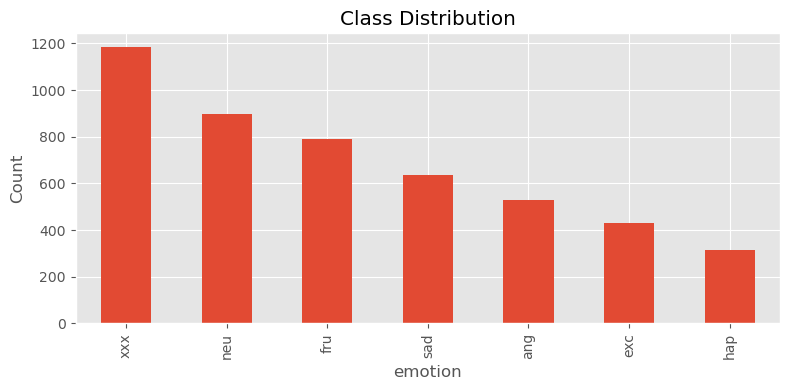

In [4]:
if not source_path.exists():
    raise FileNotFoundError(f'Missing source CSV: {source_path}')

df = pd.read_csv(source_path, nrows=USE_NROWS)

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column {TARGET_COL!r} not found. Available columns start with: {list(df.columns[:20])}")

meta_cols = [c for c in df.columns if c in METADATA_CANDIDATES]
feature_cols = [c for c in df.columns if c not in METADATA_CANDIDATES]

print(f'Data shape: {df.shape}')
print(f'Metadata columns ({len(meta_cols)}): {meta_cols}')
print(f'Feature columns ({len(feature_cols)}).')
print('Sample feature columns:', feature_cols[:10])

class_counts = df[TARGET_COL].value_counts(dropna=False)
print('Class distribution:')
print(class_counts)

fig, ax = plt.subplots(figsize=(8, 4))
class_counts.plot(kind='bar', ax=ax)
ax.set_title('Class Distribution')
ax.set_xlabel(TARGET_COL)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


## 4) Basic Cleaning, Train/Test Split, and GPU Transfer

Rows with missing labels or missing feature values are removed, then dense float32 arrays are moved onto the GPU.

In [5]:
model_df = df[[TARGET_COL] + feature_cols].copy()

rows_before = len(model_df)
model_df = model_df.dropna(subset=[TARGET_COL])
model_df = model_df.dropna(axis=0, how='any')
rows_after = len(model_df)

X = model_df[feature_cols].astype(GPU_DTYPE)
y_raw = model_df[TARGET_COL].astype(str)

label_enc = LabelEncoder()
y = label_enc.fit_transform(y_raw)
class_names = list(label_enc.classes_)
all_labels = np.arange(len(class_names))

X_train, X_test, y_train_np, y_test_np = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train_gpu = to_gpu_float32(X_train)
X_test_gpu = to_gpu_float32(X_test)
y_train_gpu = cp.asarray(y_train_np.astype(np.int32))
y_test_gpu = cp.asarray(y_test_np.astype(np.int32))

print(f'Rows before cleaning: {rows_before}')
print(f'Rows after cleaning:  {rows_after}')
print(f'Dropped rows:         {rows_before - rows_after}')
print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')
print(f'Classes: {class_names}')
print(f'GPU train dtype: {X_train_gpu.dtype}, GPU test dtype: {X_test_gpu.dtype}')


Rows before cleaning: 4779
Rows after cleaning:  4779
Dropped rows:         0
Train shape: (3823, 10480)
Test shape:  (956, 10480)
Classes: ['ang', 'exc', 'fru', 'hap', 'neu', 'sad', 'xxx']
GPU train dtype: float32, GPU test dtype: float32


## 5) GPU Baseline Models

This stage keeps everything on the GPU during preprocessing and model training. Models are evaluated sequentially to avoid GPU memory contention.

baseline_gpu models: 100%|██████████| 3/3 [00:08<00:00,  2.86s/model]

Baseline GPU metrics (all models):
       stage             model  accuracy  precision_weighted  recall_weighted  f1_weighted  f1_macro  fit_seconds  predict_seconds
baseline_gpu        gpu_logreg    0.3944              0.3947           0.3944       0.3942    0.3971       2.3333           1.2665
baseline_gpu gpu_random_forest    0.3086              0.5365           0.3086       0.2323    0.1902       4.7790           0.0860
baseline_gpu           gpu_knn    0.2678              0.3603           0.2678       0.2261    0.1947       0.0047           0.0921

[gpu_logreg] classification report (baseline_gpu):
              precision    recall  f1-score   support

         ang       0.49      0.49      0.49       106
         exc       0.47      0.47      0.47        86
         fru       0.36      0.39      0.37       158
         hap       0.29      0.24      0.26        62
         neu       0.40      0.38      0.39       180
         sad       0.46      0.44      0.45       127
         x

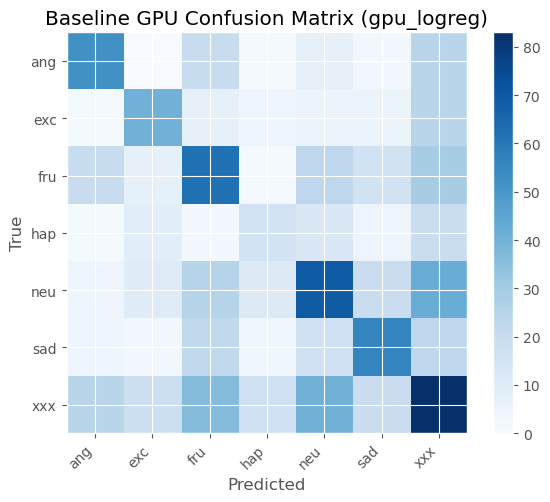

In [6]:
baseline_scaler = CuStandardScaler()
X_train_scaled_gpu = baseline_scaler.fit_transform(X_train_gpu)
X_test_scaled_gpu = baseline_scaler.transform(X_test_gpu)

MODEL_SPECS = {
    'gpu_logreg': {
        'builder': lambda: CuLogisticRegression(max_iter=4000, tol=1e-4),
        'uses_scaled': True,
    },
    'gpu_random_forest': {
        'builder': lambda: CuRandomForestClassifier(
            n_estimators=400,
            max_depth=24,
            n_bins=128,
            random_state=RANDOM_STATE,
        ),
        'uses_scaled': False,
    },
}

if HAS_GPU_KNN:
    MODEL_SPECS['gpu_knn'] = {
        'builder': lambda: CuKNeighborsClassifier(n_neighbors=15),
        'uses_scaled': True,
    }


def evaluate_gpu_models(model_specs, X_train_raw, X_train_scaled, y_train, X_test_raw, X_test_scaled, y_test, stage_name: str):
    rows = []
    preds = {}

    for model_name, spec in tqdm(model_specs.items(), total=len(model_specs), desc=f'{stage_name} models', unit='model'):
        model = spec['builder']()
        Xtr = X_train_scaled if spec['uses_scaled'] else X_train_raw
        Xte = X_test_scaled if spec['uses_scaled'] else X_test_raw

        fit_start = perf_counter()
        model.fit(Xtr, y_train)
        fit_seconds = perf_counter() - fit_start

        pred_start = perf_counter()
        y_pred_gpu = model.predict(Xte)
        pred_seconds = perf_counter() - pred_start

        y_pred = to_cpu_array(y_pred_gpu).astype(int).reshape(-1)
        preds[model_name] = y_pred

        rows.append({
            'stage': stage_name,
            'model': model_name,
            'accuracy': accuracy_score(y_test, y_pred),
            'precision_weighted': precision_score(y_test, y_pred, average='weighted', zero_division=0),
            'recall_weighted': recall_score(y_test, y_pred, average='weighted', zero_division=0),
            'f1_weighted': f1_score(y_test, y_pred, average='weighted'),
            'f1_macro': f1_score(y_test, y_pred, average='macro'),
            'fit_seconds': fit_seconds,
            'predict_seconds': pred_seconds,
        })

    metrics_df = pd.DataFrame(rows).sort_values('f1_weighted', ascending=False, ignore_index=True)
    return metrics_df, preds


baseline_results, baseline_preds = evaluate_gpu_models(
    MODEL_SPECS,
    X_train_gpu,
    X_train_scaled_gpu,
    y_train_gpu,
    X_test_gpu,
    X_test_scaled_gpu,
    y_test_np,
    stage_name='baseline_gpu',
)

print('Baseline GPU metrics (all models):')
print(baseline_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

for model_name in baseline_results['model']:
    print(f'\n[{model_name}] classification report (baseline_gpu):')
    print(classification_report(
        y_test_np,
        baseline_preds[model_name],
        labels=all_labels,
        target_names=class_names,
        zero_division=0,
    ))

best_baseline_model = baseline_results.loc[0, 'model']
plot_confusion(y_test_np, baseline_preds[best_baseline_model], class_names, f'Baseline GPU Confusion Matrix ({best_baseline_model})')

base_acc = float(baseline_results.loc[0, 'accuracy'])
base_f1 = float(baseline_results.loc[0, 'f1_weighted'])


## 6) GPU PCA on Standardized Features

This cell fits `cuML PCA` on standardized training features, keeps the transformed matrices on GPU, and reports explained variance.

Original feature count: 10480
GPU PCA component count: 512
Total explained variance: 0.5004
GPU PCA fit+transform time (s): 2.1992
Top 10 GPU PCA components by explained variance:
      component  explained_variance_ratio  cumulative_explained_variance
0  pca_gpu_0000                  0.003628                       0.003628
1  pca_gpu_0001                  0.003533                       0.007162
2  pca_gpu_0002                  0.003406                       0.010568
3  pca_gpu_0003                  0.002820                       0.013387
4  pca_gpu_0004                  0.002769                       0.016156
5  pca_gpu_0005                  0.002609                       0.018765
6  pca_gpu_0006                  0.002596                       0.021361
7  pca_gpu_0007                  0.002588                       0.023949
8  pca_gpu_0008                  0.002585                       0.026534
9  pca_gpu_0009                  0.002570                       0.029104


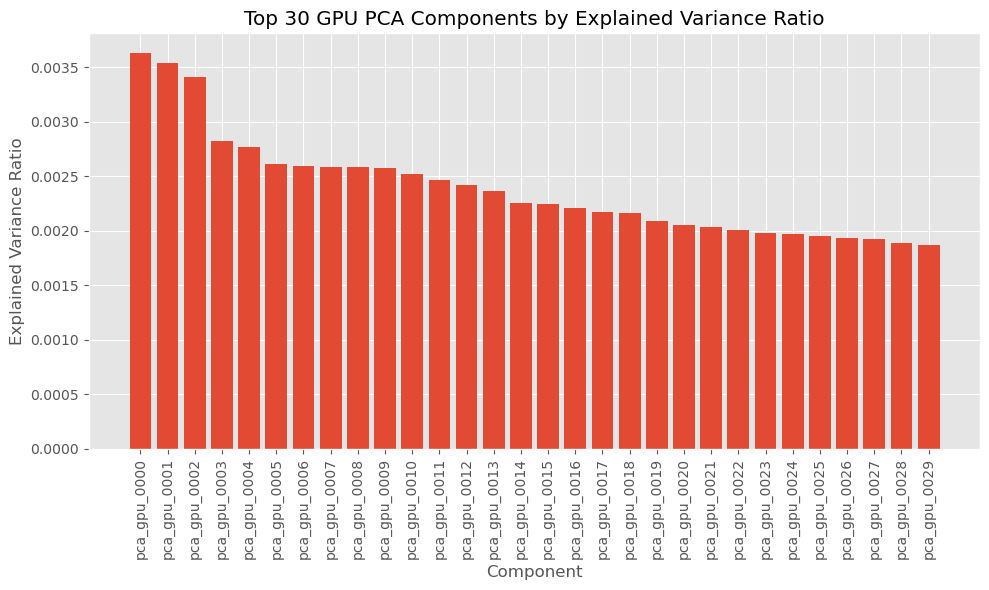

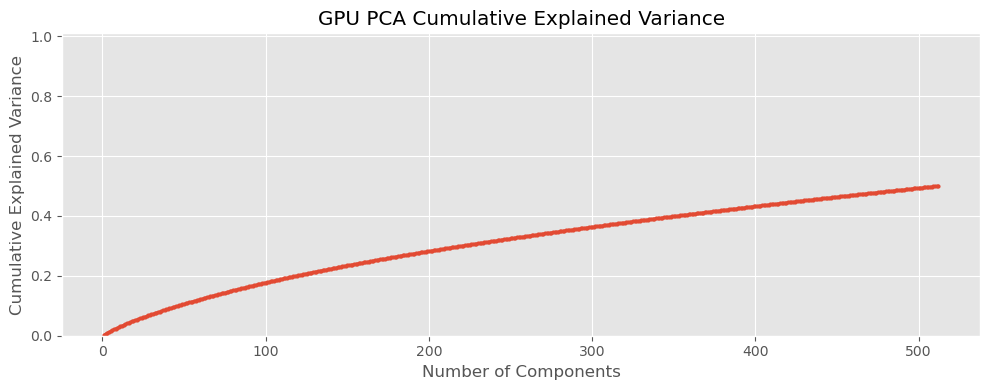

In [11]:
pca = CuPCA(n_components=PCA_COMPONENTS)

pca_fit_start = perf_counter()
X_train_sel_gpu = pca.fit_transform(X_train_scaled_gpu)
X_test_sel_gpu = pca.transform(X_test_scaled_gpu)
pca_fit_seconds = perf_counter() - pca_fit_start

explained = to_cpu_array(pca.explained_variance_ratio_).astype(float)
cumulative = np.cumsum(explained)
component_names = [f'pca_gpu_{i:04d}' for i in range(X_train_sel_gpu.shape[1])]
selected_features = component_names

print(f'Original feature count: {X_train.shape[1]}')
print(f'GPU PCA component count: {X_train_sel_gpu.shape[1]}')
print(f'Total explained variance: {cumulative[-1]:.4f}')
print(f'GPU PCA fit+transform time (s): {pca_fit_seconds:.4f}')

rank_df = pd.DataFrame({
    'component': component_names,
    'explained_variance_ratio': explained,
    'cumulative_explained_variance': cumulative,
})

print('Top 10 GPU PCA components by explained variance:')
print(rank_df.head(10))

plot_n = min(30, len(rank_df))
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(rank_df['component'][:plot_n], rank_df['explained_variance_ratio'][:plot_n])
ax.set_title(f'Top {plot_n} GPU PCA Components by Explained Variance Ratio')
ax.set_xlabel('Component')
ax.set_ylabel('Explained Variance Ratio')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(1, len(cumulative) + 1), cumulative, marker='o', markersize=2)
ax.set_title('GPU PCA Cumulative Explained Variance')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_ylim(0, 1.01)
plt.tight_layout()
plt.show()


## 7) GPU Models After PCA

The same GPU model family is retrained on GPU PCA features so we can compare raw-feature performance against reduced representations.

pca_gpu models: 100%|██████████| 3/3 [00:04<00:00,  1.39s/model]

Post-GPU-PCA metrics (all models):
  stage             model  accuracy  precision_weighted  recall_weighted  f1_weighted  f1_macro  fit_seconds  predict_seconds
pca_gpu gpu_random_forest    0.3975              0.4275           0.3975       0.3974    0.3878       2.7361           0.3014
pca_gpu        gpu_logreg    0.3672              0.3742           0.3672       0.3670    0.3568       1.1151           0.0006
pca_gpu           gpu_knn    0.3295              0.3316           0.3295       0.3260    0.3096       0.0023           0.0025

[gpu_random_forest] classification report (pca_gpu):
              precision    recall  f1-score   support

         ang       0.62      0.45      0.52       106
         exc       0.45      0.20      0.27        86
         fru       0.39      0.41      0.40       158
         hap       0.40      0.19      0.26        62
         neu       0.36      0.41      0.38       180
         sad       0.61      0.41      0.49       127
         xxx       0.32     

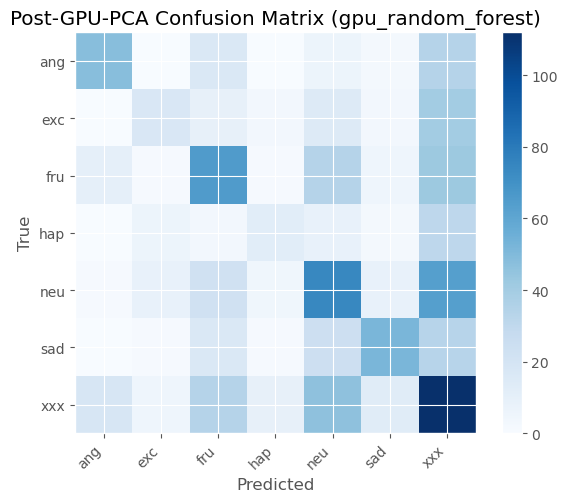


Metric delta by model (GPU PCA - baseline GPU):
            model  accuracy_baseline  precision_weighted_baseline  recall_weighted_baseline  f1_weighted_baseline  f1_macro_baseline  fit_seconds_baseline  predict_seconds_baseline  accuracy_selected  precision_weighted_selected  recall_weighted_selected  f1_weighted_selected  f1_macro_selected  fit_seconds_selected  predict_seconds_selected  accuracy_delta  precision_weighted_delta  recall_weighted_delta  f1_weighted_delta  f1_macro_delta  fit_seconds_delta  predict_seconds_delta
gpu_random_forest             0.3086                       0.5365                    0.3086                0.2323             0.1902                4.7790                    0.0860             0.3975                       0.4275                    0.3975                0.3974             0.3878                2.7361                    0.3014          0.0889                   -0.1090                 0.0889             0.1651          0.1975            -2.0429   

In [12]:
selected_results, selected_preds = evaluate_gpu_models(
    MODEL_SPECS,
    X_train_sel_gpu,
    X_train_sel_gpu,
    y_train_gpu,
    X_test_sel_gpu,
    X_test_sel_gpu,
    y_test_np,
    stage_name='pca_gpu',
)

print('Post-GPU-PCA metrics (all models):')
print(selected_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

for model_name in selected_results['model']:
    print(f'\n[{model_name}] classification report (pca_gpu):')
    print(classification_report(
        y_test_np,
        selected_preds[model_name],
        labels=all_labels,
        target_names=class_names,
        zero_division=0,
    ))

best_selected_model = selected_results.loc[0, 'model']
plot_confusion(y_test_np, selected_preds[best_selected_model], class_names, f'Post-GPU-PCA Confusion Matrix ({best_selected_model})')

comparison_df = baseline_results[['model', 'accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'f1_macro', 'fit_seconds', 'predict_seconds']].merge(
    selected_results[['model', 'accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'f1_macro', 'fit_seconds', 'predict_seconds']],
    on='model',
    suffixes=('_baseline', '_selected'),
)
comparison_df['accuracy_delta'] = comparison_df['accuracy_selected'] - comparison_df['accuracy_baseline']
comparison_df['precision_weighted_delta'] = comparison_df['precision_weighted_selected'] - comparison_df['precision_weighted_baseline']
comparison_df['recall_weighted_delta'] = comparison_df['recall_weighted_selected'] - comparison_df['recall_weighted_baseline']
comparison_df['f1_weighted_delta'] = comparison_df['f1_weighted_selected'] - comparison_df['f1_weighted_baseline']
comparison_df['f1_macro_delta'] = comparison_df['f1_macro_selected'] - comparison_df['f1_macro_baseline']
comparison_df['fit_seconds_delta'] = comparison_df['fit_seconds_selected'] - comparison_df['fit_seconds_baseline']
comparison_df['predict_seconds_delta'] = comparison_df['predict_seconds_selected'] - comparison_df['predict_seconds_baseline']
comparison_df = comparison_df.sort_values('f1_weighted_selected', ascending=False, ignore_index=True)

print('\nMetric delta by model (GPU PCA - baseline GPU):')
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

sel_acc = float(selected_results.loc[0, 'accuracy'])
sel_f1 = float(selected_results.loc[0, 'f1_weighted'])


## 8) Save Artifacts

This exports GPU PCA component names, explained variance, transformed train/test matrices, and run metadata.

In [13]:
out_dir = REPO_ROOT / 'feature_selection' / 'pca' / 'select_pca' / 'artifacts_gpu'
out_dir.mkdir(parents=True, exist_ok=True)

selected_feature_path = out_dir / f'{DATASET_KEY}_gpu_pca_components.json'
rank_path = out_dir / f'{DATASET_KEY}_gpu_pca_explained_variance.csv'
train_sel_path = out_dir / f'{DATASET_KEY}_X_train_gpu_pca.csv'
test_sel_path = out_dir / f'{DATASET_KEY}_X_test_gpu_pca.csv'
meta_path = out_dir / f'{DATASET_KEY}_gpu_run_metadata.json'

artifact_progress = tqdm(total=5, desc='saving artifacts', unit='file')

with selected_feature_path.open('w', encoding='utf-8') as f:
    json.dump(selected_features, f, indent=2)
artifact_progress.update(1)

rank_df.to_csv(rank_path, index=False)
artifact_progress.update(1)

X_train_sel_df = pd.DataFrame(to_cpu_array(X_train_sel_gpu), columns=selected_features)
X_test_sel_df = pd.DataFrame(to_cpu_array(X_test_sel_gpu), columns=selected_features)
X_train_sel_df.to_csv(train_sel_path, index=False)
artifact_progress.update(1)
X_test_sel_df.to_csv(test_sel_path, index=False)
artifact_progress.update(1)

baseline_records = baseline_results.to_dict(orient='records')
selected_records = selected_results.to_dict(orient='records')
comparison_records = comparison_df.to_dict(orient='records')

for collection in (baseline_records, selected_records, comparison_records):
    for row in collection:
        for key, value in list(row.items()):
            if isinstance(value, (np.floating, float)):
                row[key] = float(value)
            elif isinstance(value, (np.integer, int)):
                row[key] = int(value)

run_meta = {
    'dataset_key': DATASET_KEY,
    'source_path': str(source_path),
    'target_col': TARGET_COL,
    'rows_used': int(len(model_df)),
    'original_features': int(X_train.shape[1]),
    'pca_components_config': PCA_COMPONENTS,
    'pca_components_effective': int(X_train_sel_gpu.shape[1]),
    'pca_explained_variance_total': float(cumulative[-1]),
    'pca_fit_seconds': float(pca_fit_seconds),
    'random_state': RANDOM_STATE,
    'test_size': TEST_SIZE,
    'gpu_name': str(gpu_name),
    'gpu_device_id': int(device_id),
    'baseline_stage': 'baseline_gpu',
    'selected_stage': 'pca_gpu',
    'best_baseline_model': str(baseline_results.loc[0, 'model']),
    'best_pca_model': str(selected_results.loc[0, 'model']),
    'baseline_accuracy': float(base_acc),
    'baseline_f1_weighted': float(base_f1),
    'pca_accuracy': float(sel_acc),
    'pca_f1_weighted': float(sel_f1),
    'baseline_model_metrics': baseline_records,
    'pca_model_metrics': selected_records,
    'model_metric_deltas': comparison_records,
}

with meta_path.open('w', encoding='utf-8') as f:
    json.dump(run_meta, f, indent=2)
artifact_progress.update(1)
artifact_progress.close()

print('Saved artifacts:')
print('-', selected_feature_path)
print('-', rank_path)
print('-', train_sel_path)
print('-', test_sel_path)
print('-', meta_path)


saving artifacts: 100%|██████████| 5/5 [00:01<00:00,  3.14file/s]

Saved artifacts:
- /mnt/f/Speech-Emotion-Recognition/feature_selection/pca/select_pca/artifacts_gpu/tfidf_gpu_pca_components.json
- /mnt/f/Speech-Emotion-Recognition/feature_selection/pca/select_pca/artifacts_gpu/tfidf_gpu_pca_explained_variance.csv
- /mnt/f/Speech-Emotion-Recognition/feature_selection/pca/select_pca/artifacts_gpu/tfidf_X_train_gpu_pca.csv
- /mnt/f/Speech-Emotion-Recognition/feature_selection/pca/select_pca/artifacts_gpu/tfidf_X_test_gpu_pca.csv
- /mnt/f/Speech-Emotion-Recognition/feature_selection/pca/select_pca/artifacts_gpu/tfidf_gpu_run_metadata.json


## 9) Notes for Next GPU Methods

After this GPU PCA baseline, useful next directions are:
- XGBoost with `device=\"cuda\"` for tree ensembles
- cuML UMAP before classification
- cuML k-means or nearest-neighbor analysis on reduced embeddings
- comparing dense GPU PCA against sparse CPU `TruncatedSVD` for TF-IDF

In [14]:
# Delta summary (GPU PCA - baseline GPU)
if 'comparison_df' not in globals():
    raise RuntimeError('comparison_df not found. Run the training/evaluation cells first.')

delta_cols = [
    'model',
    'accuracy_baseline',
    'accuracy_selected',
    'accuracy_delta',
    'precision_weighted_baseline',
    'precision_weighted_selected',
    'precision_weighted_delta',
    'recall_weighted_baseline',
    'recall_weighted_selected',
    'recall_weighted_delta',
    'f1_weighted_baseline',
    'f1_weighted_selected',
    'f1_weighted_delta',
    'f1_macro_baseline',
    'f1_macro_selected',
    'f1_macro_delta',
    'fit_seconds_baseline',
    'fit_seconds_selected',
    'fit_seconds_delta',
]

delta_table = comparison_df[delta_cols].copy().sort_values('f1_weighted_delta', ascending=False, ignore_index=True)

print('Delta table (GPU PCA - baseline GPU):')
print(delta_table.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print('\nDelta accuracy only:')
print(
    delta_table[['model', 'accuracy_baseline', 'accuracy_selected', 'accuracy_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

print('\nDelta weighted F1 only:')
print(
    delta_table[['model', 'f1_weighted_baseline', 'f1_weighted_selected', 'f1_weighted_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

best_gain_row = delta_table.iloc[0]
print(
    f"\nBest weighted-F1 delta after GPU PCA: {best_gain_row['model']} | "
    f"Delta F1-weighted={best_gain_row['f1_weighted_delta']:+.4f}, "
    f"Delta Accuracy={best_gain_row['accuracy_delta']:+.4f}"
)


Delta table (GPU PCA - baseline GPU):
            model  accuracy_baseline  accuracy_selected  accuracy_delta  precision_weighted_baseline  precision_weighted_selected  precision_weighted_delta  recall_weighted_baseline  recall_weighted_selected  recall_weighted_delta  f1_weighted_baseline  f1_weighted_selected  f1_weighted_delta  f1_macro_baseline  f1_macro_selected  f1_macro_delta  fit_seconds_baseline  fit_seconds_selected  fit_seconds_delta
gpu_random_forest             0.3086             0.3975          0.0889                       0.5365                       0.4275                   -0.1090                    0.3086                    0.3975                 0.0889                0.2323                0.3974             0.1651             0.1902             0.3878          0.1975                4.7790                2.7361            -2.0429
          gpu_knn             0.2678             0.3295          0.0617                       0.3603                       0.3316           